In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from uncertainties import ufloat
import uncertainties.unumpy as unp

2.9773895836543826e-08 0.9999999999999999
5.588342059433274e-08 0.9999999999999997
9.294744997014435e-08 0.9999999999999999
1.4843177164634086e-07 1.0000000000000002
2.758825328441659e-07 1.0
4.0652784817310225e-07 1.0
7.619710891063865e-07 1.0000000000000002
1.0580551095081113e-06 0.9999999999999999
1.707636967058089e-06 1.0000000000000002
2.614571593300687e-06 1.0000000000000002
3.906812791102629e-06 1.0000000000000004
5.709208855734923e-06 1.0000000000000002
8.144333875232737e-06 1.0000000000000002
1.1359239435164388e-05 1.0
1.545361613102237e-05 1.0000000000000002
2.0413316994092196e-05 0.9999999999999999
2.5963681362029872e-05 1.0
3.150439691238376e-05 1.0
3.6252809114768645e-05 1.0000000000000002
3.991806489816041e-05 1.0000000000000002
4.4340088131843294e-05 0.9999999999999997
5.580873227830314e-05 1.0


C:\Users\jleng\AppData\Local\Temp\ipykernel_14944\131360025.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 3, figsize=(18, 6))


8.314062735103431e-05 1.0000000000000002
0.00013167383037883198 1.0
0.0002033670166279215 1.0000000000000002
0.0002983389219788177 1.0
0.00041418388510193656 0.9999999999999999
0.0005449357642772372 1.0
0.0006807236364745722 1.0
0.0008084773936910023 0.9999999999999999
0.0009137186399598914 1.0000000000000002


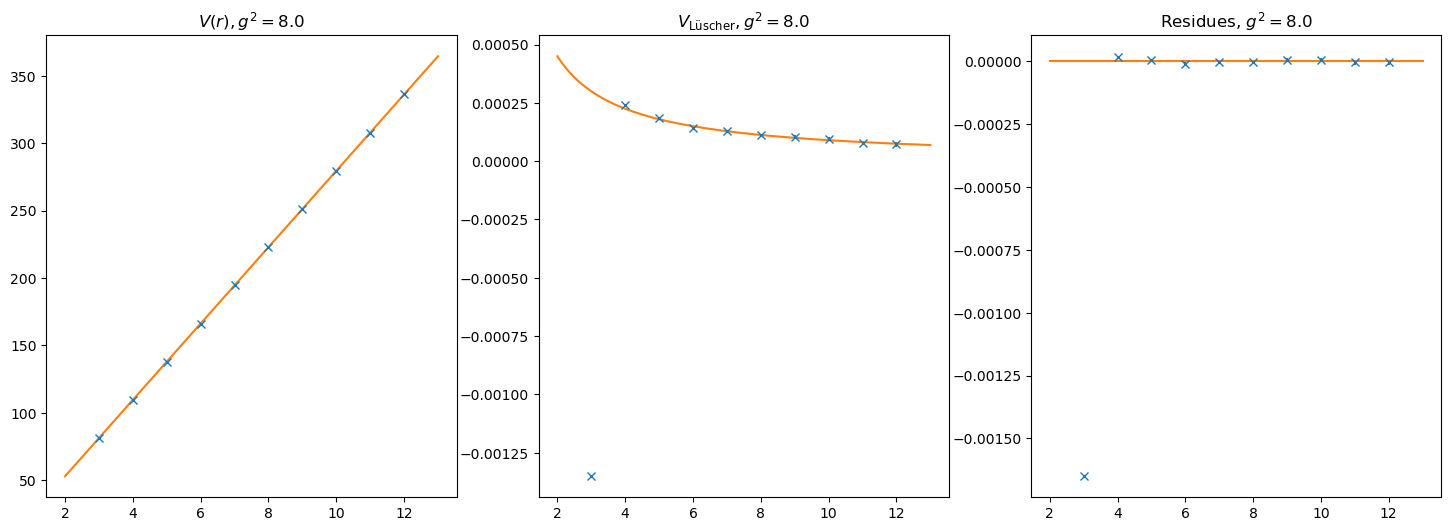

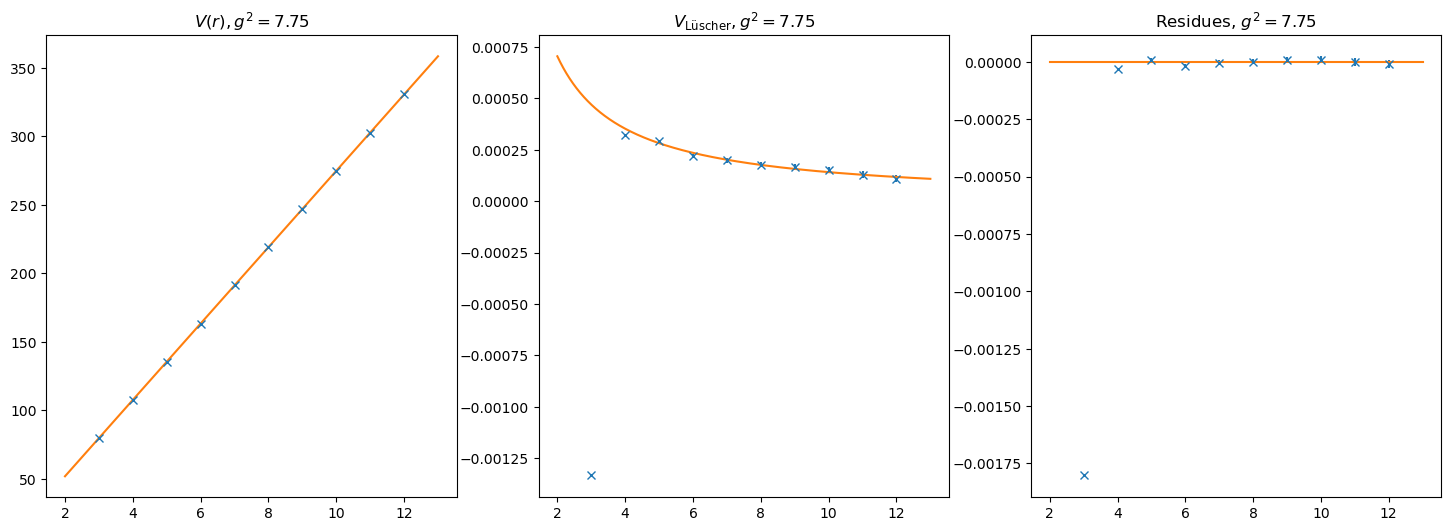

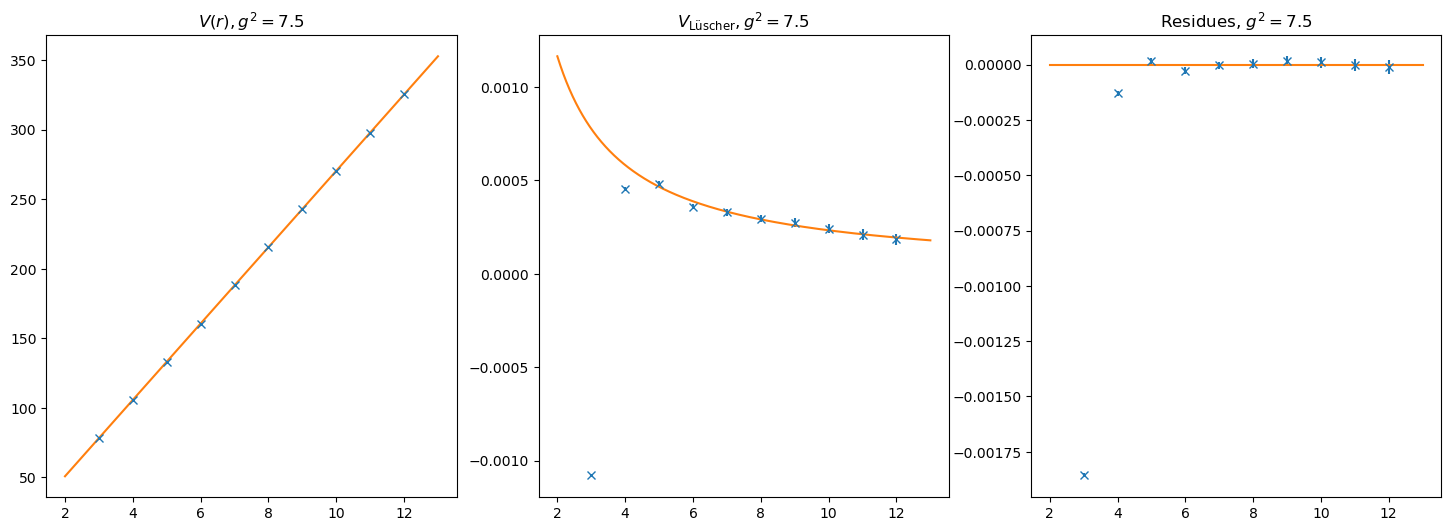

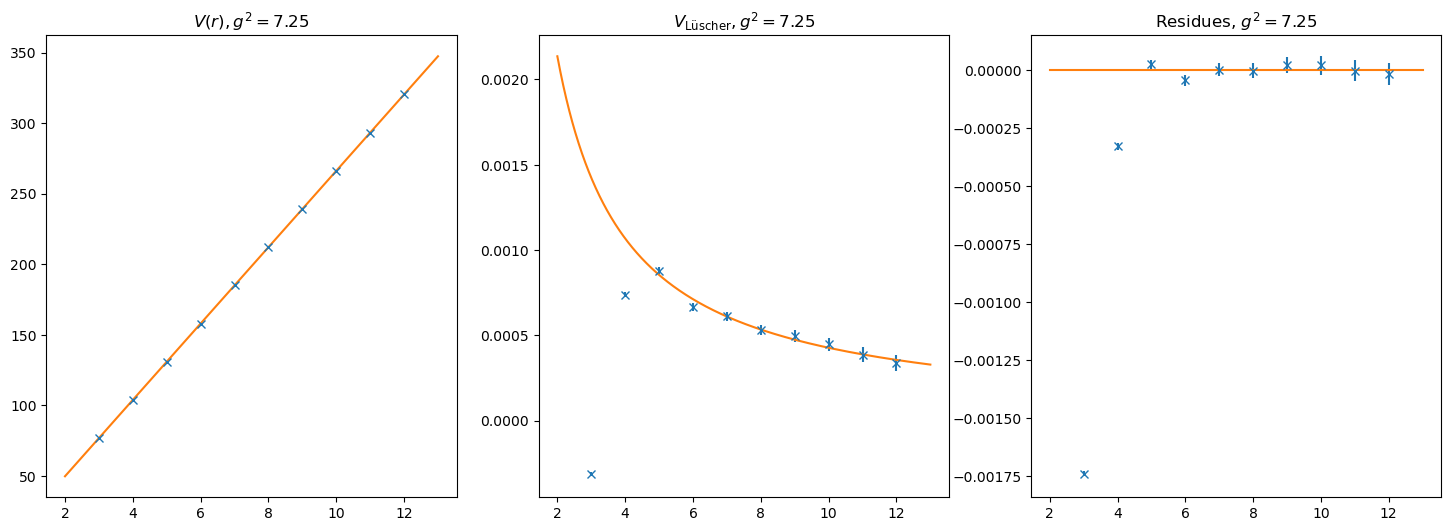

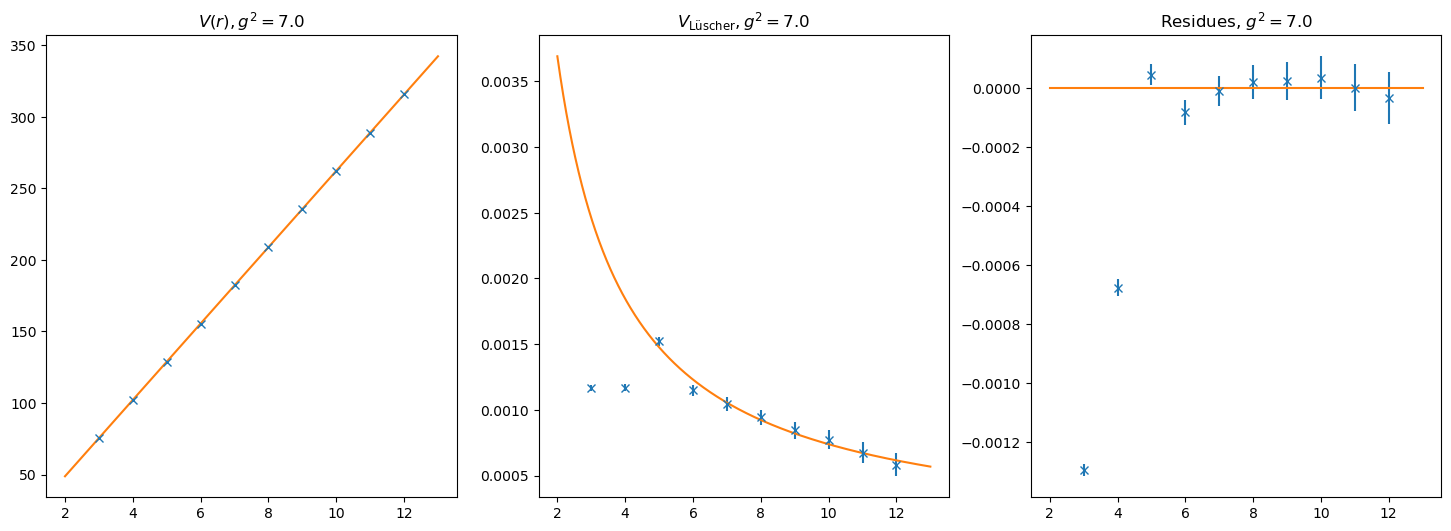

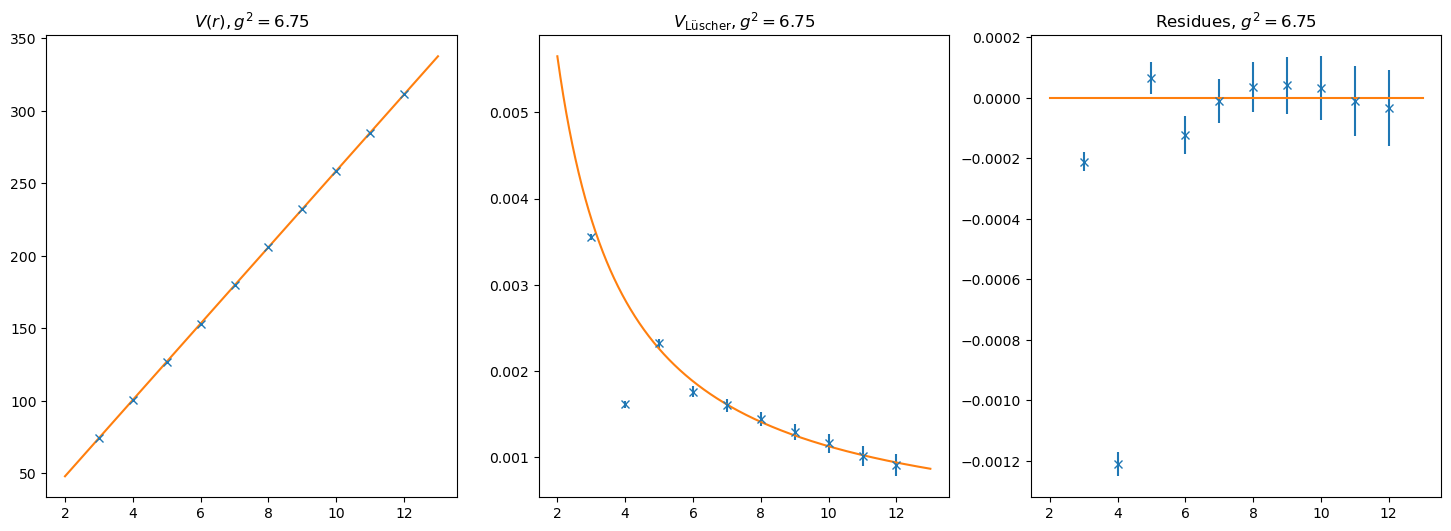

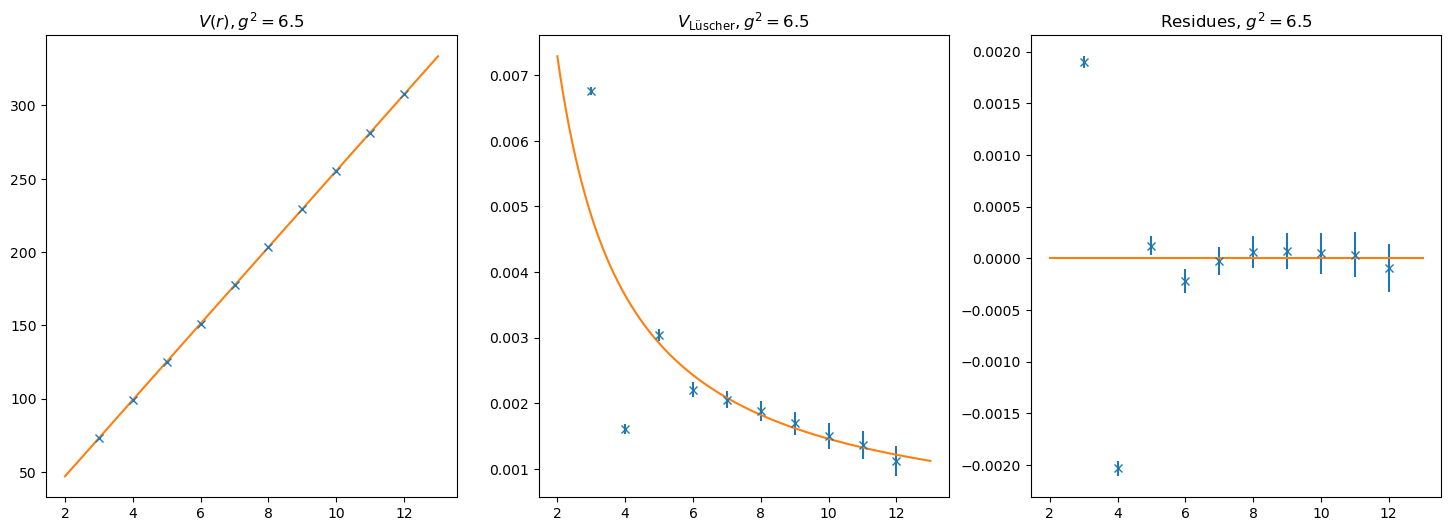

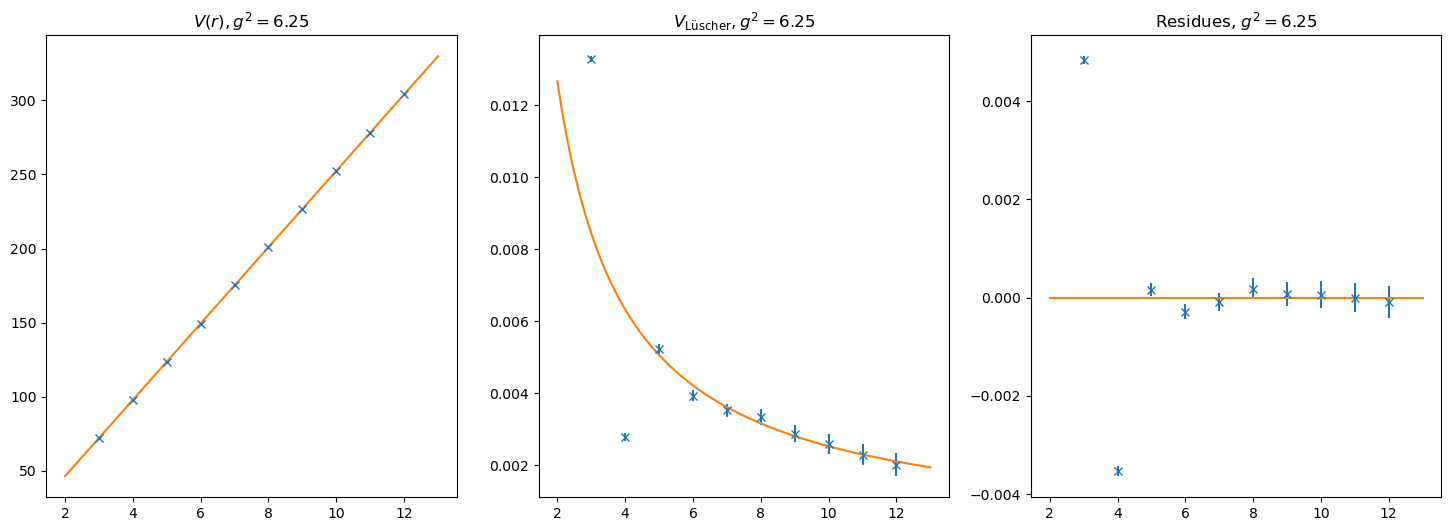

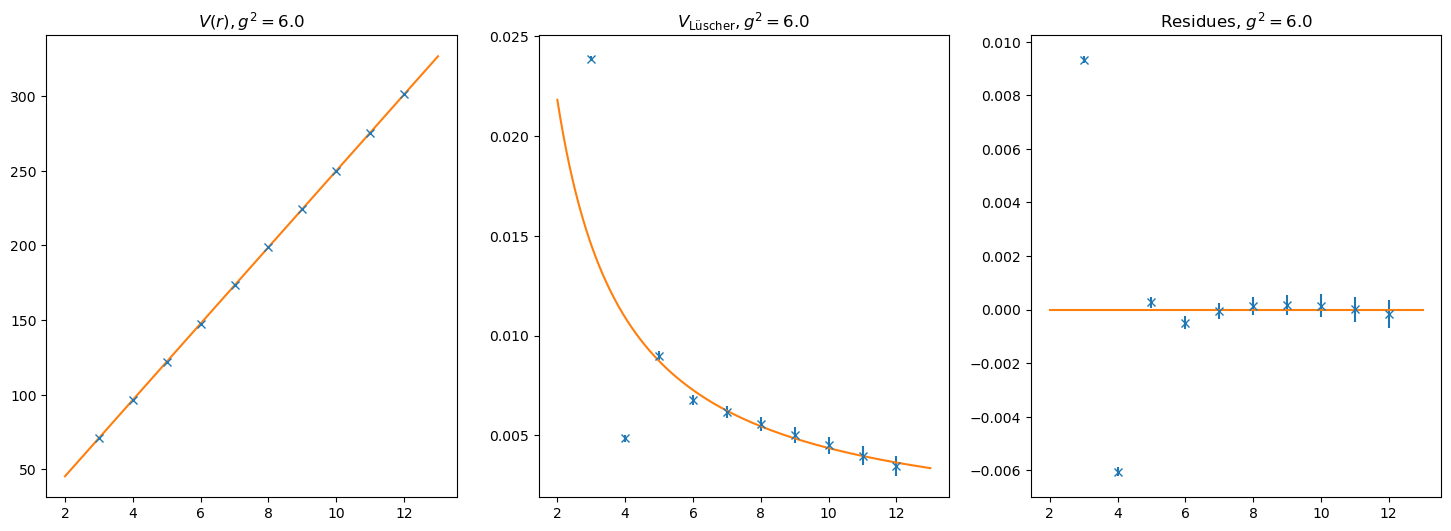

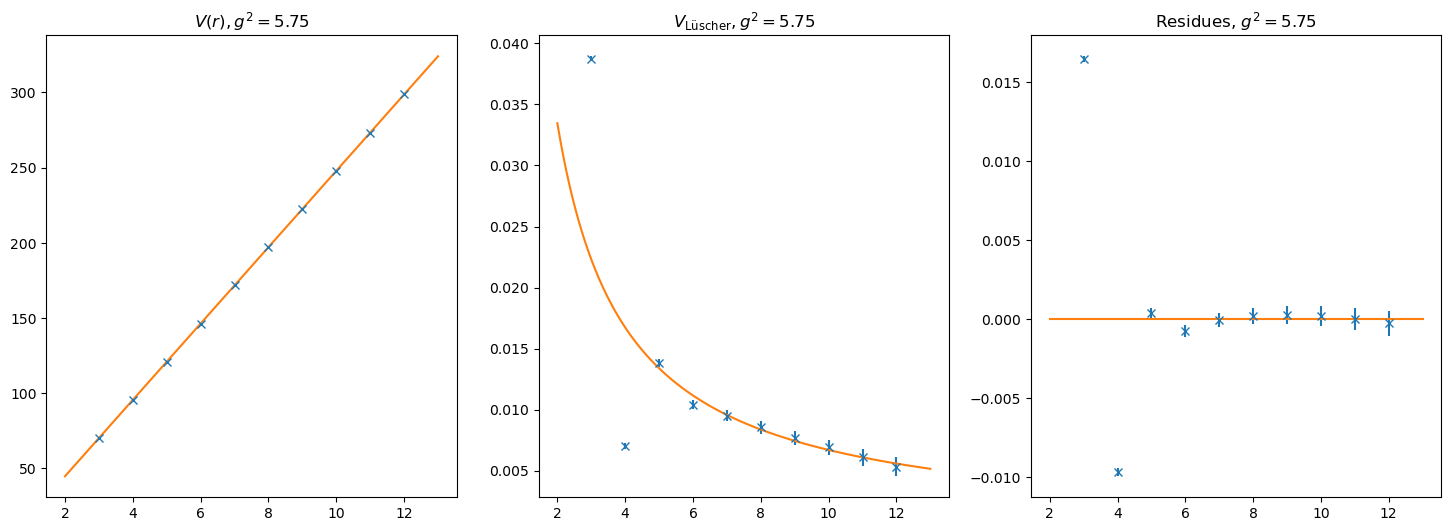

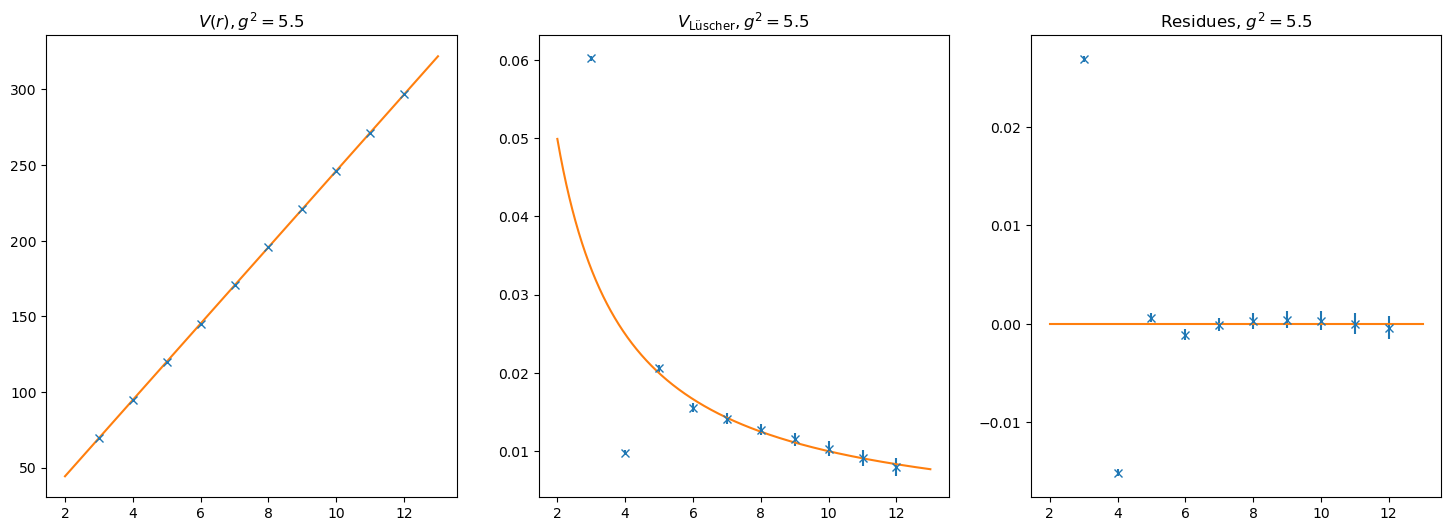

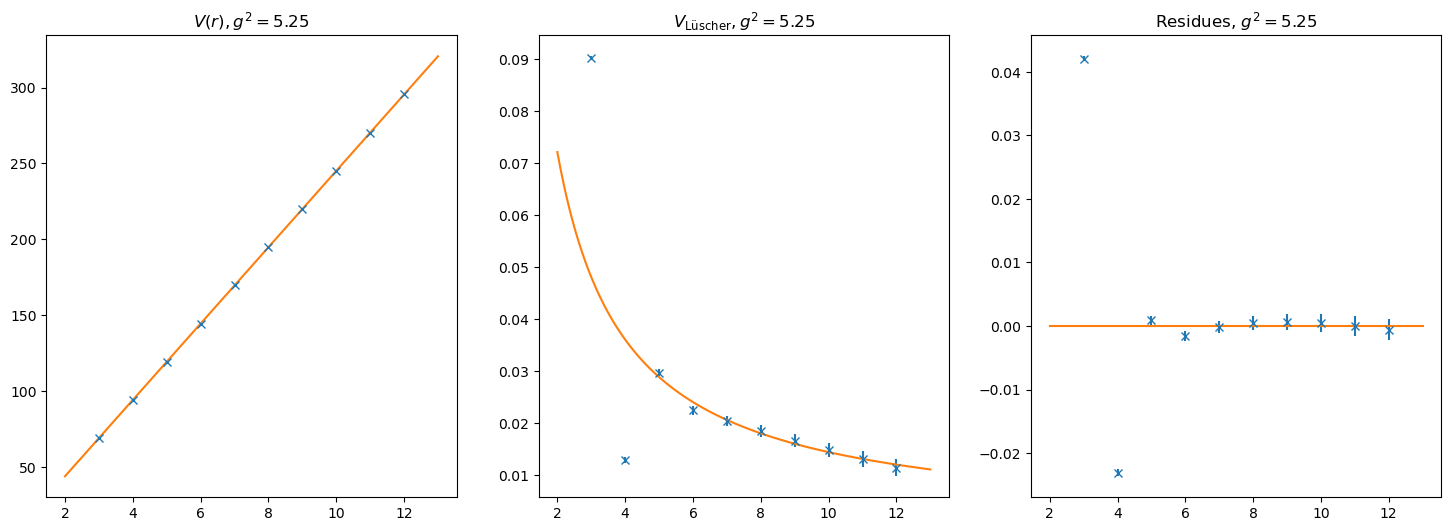

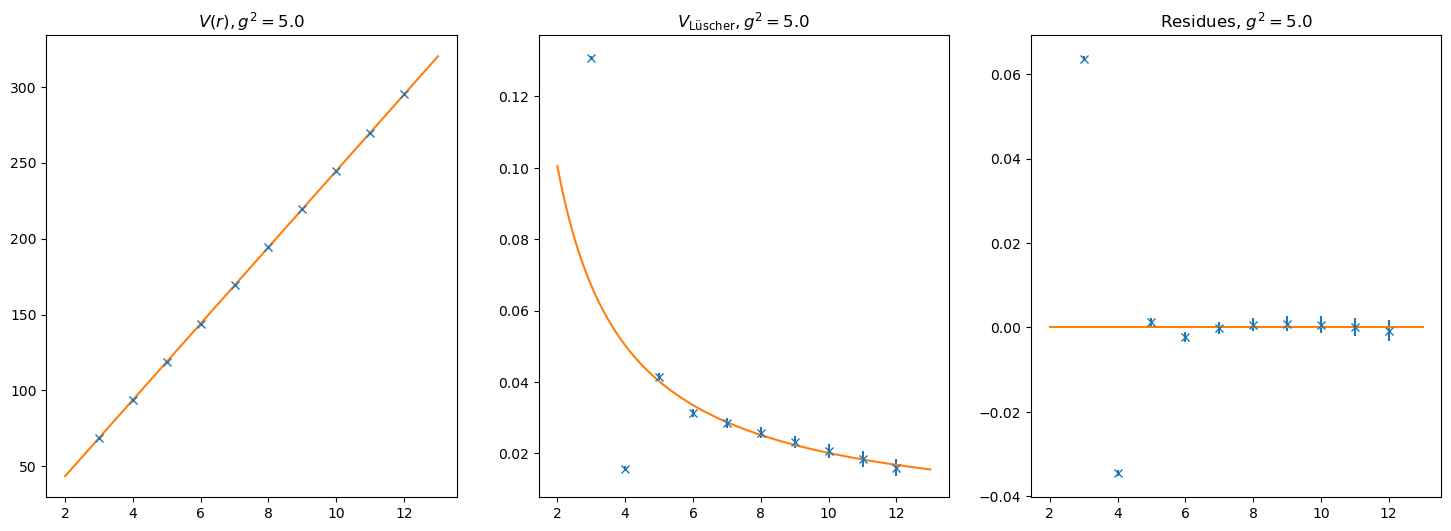

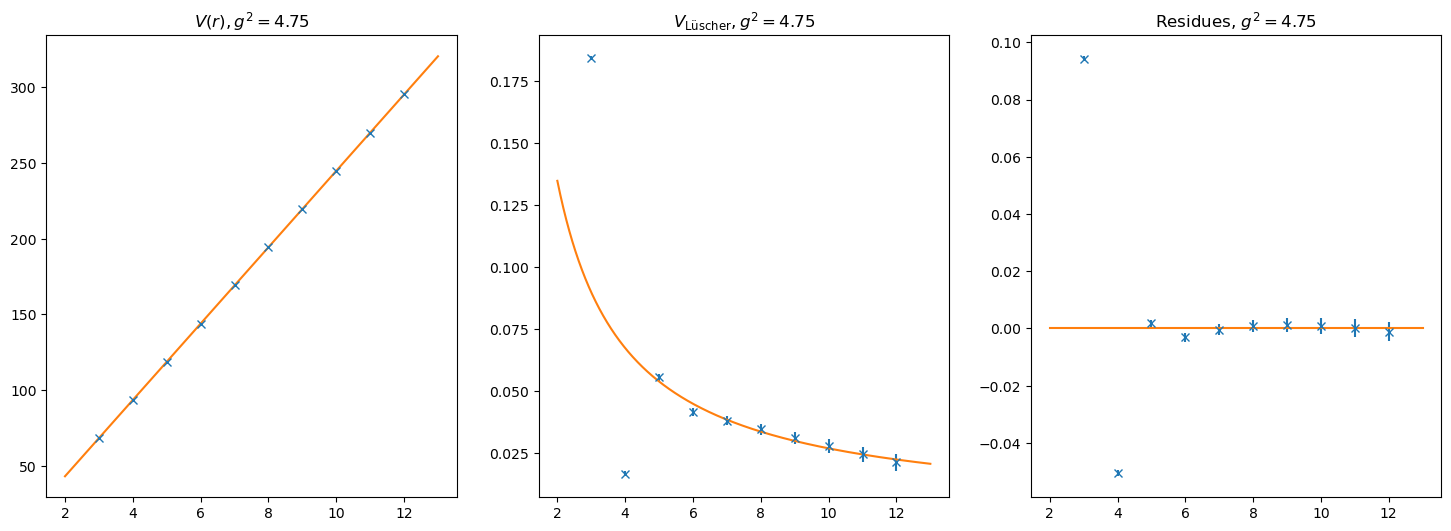

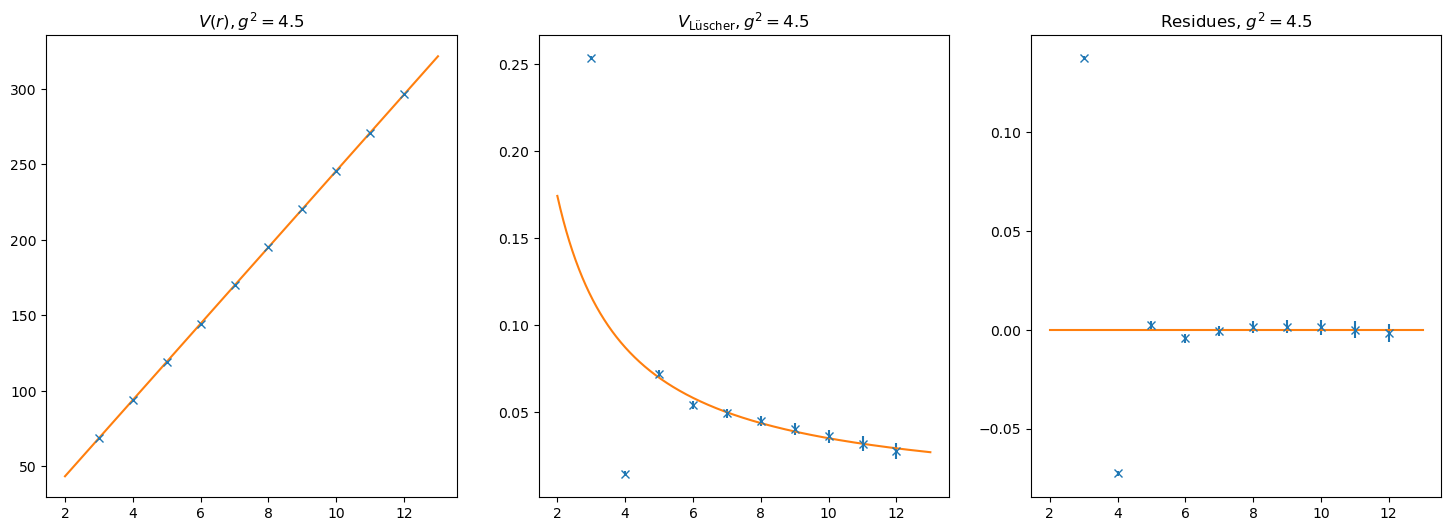

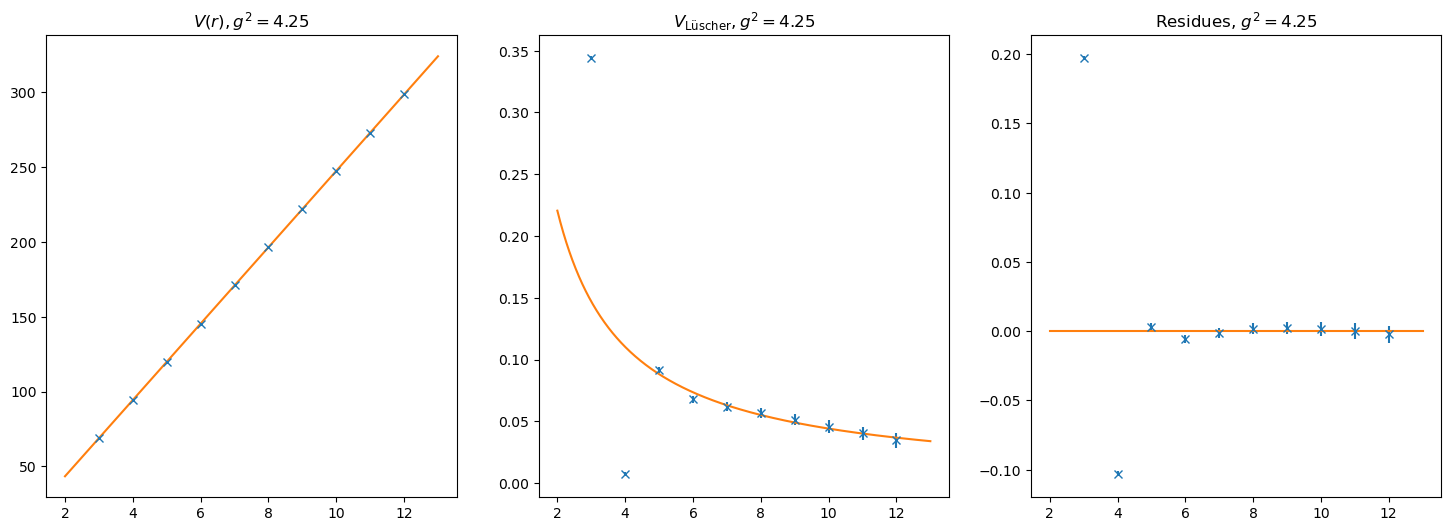

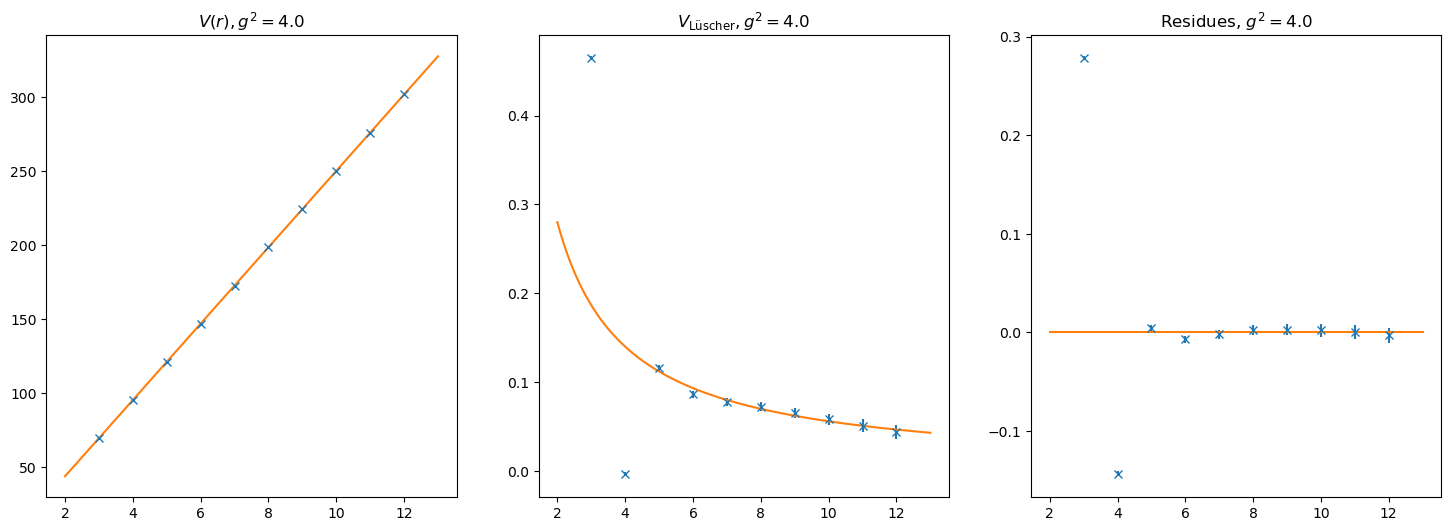

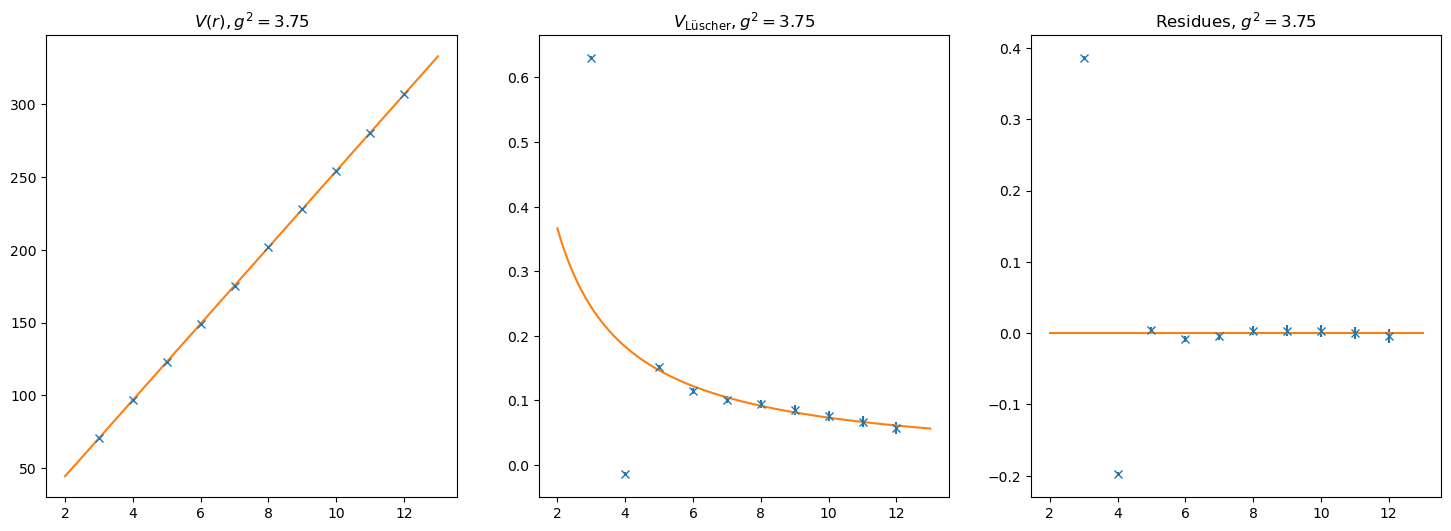

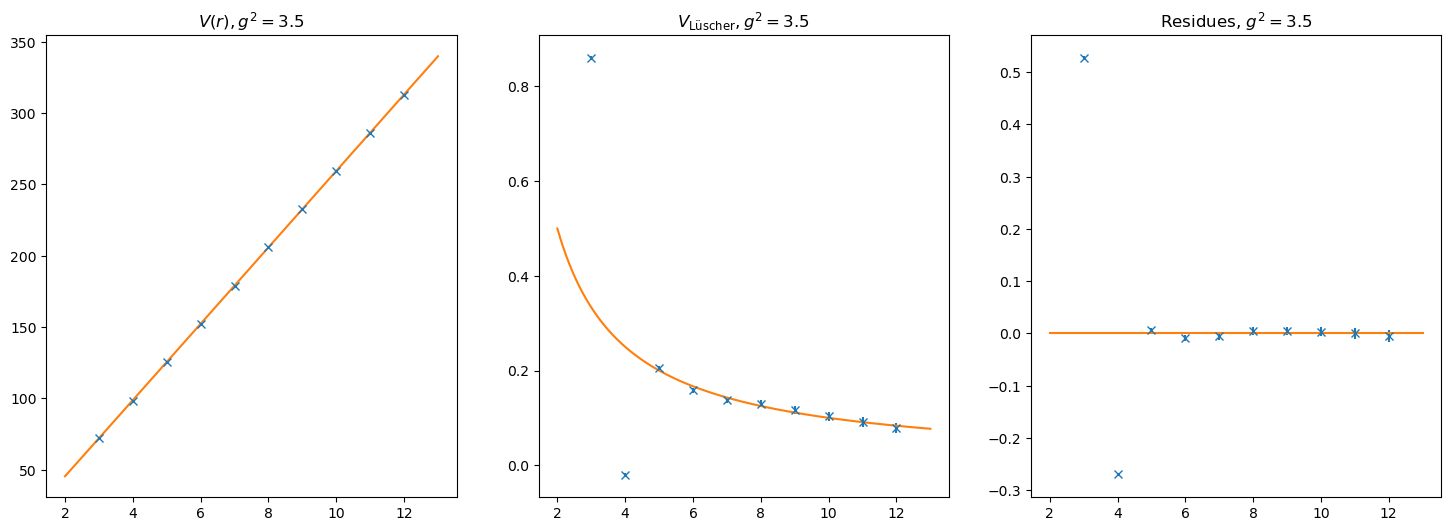

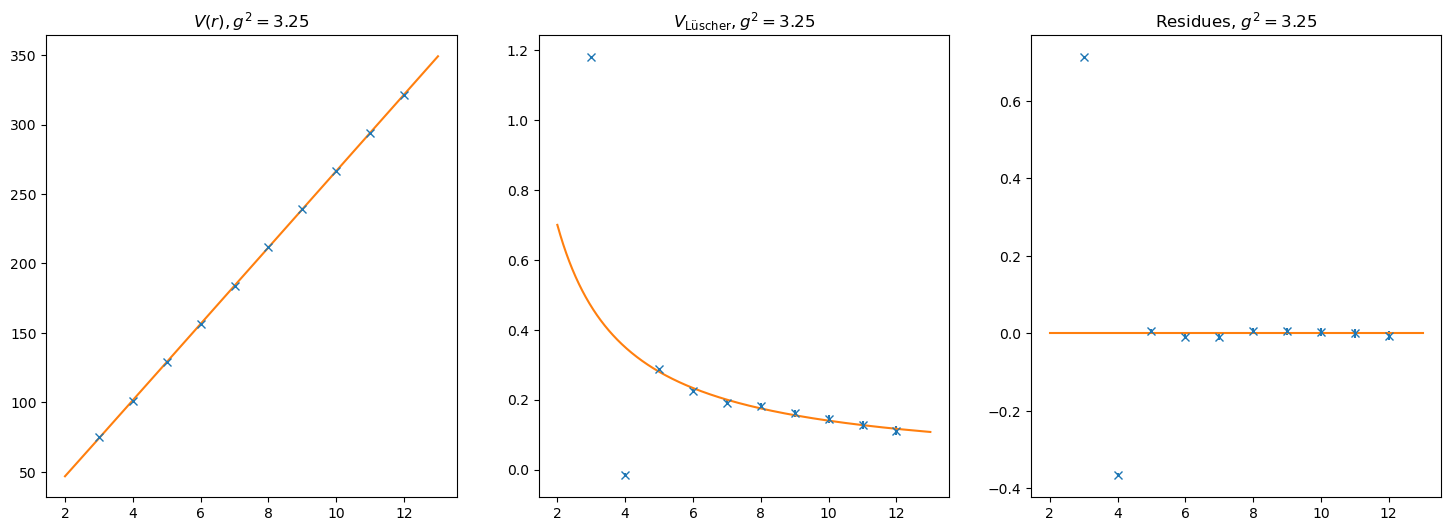

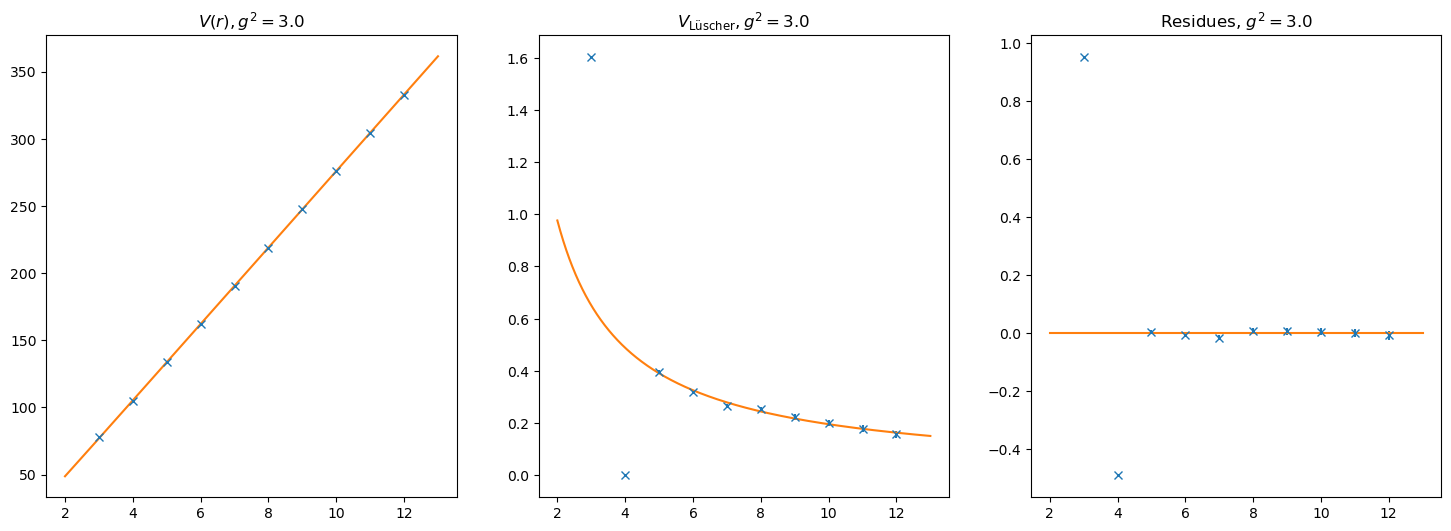

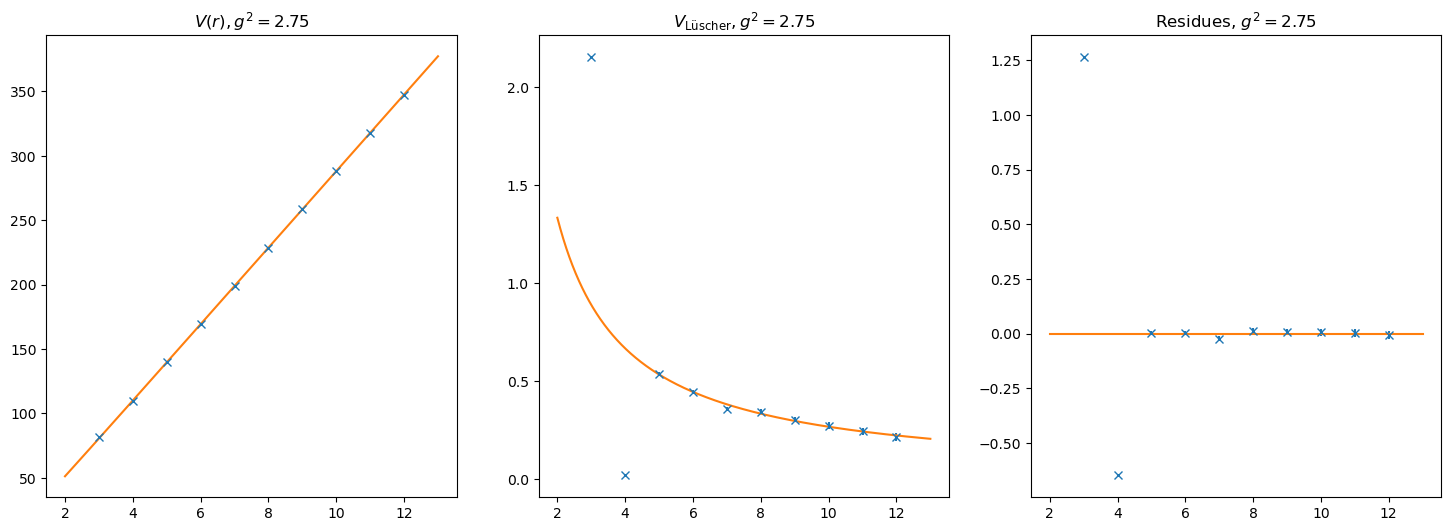

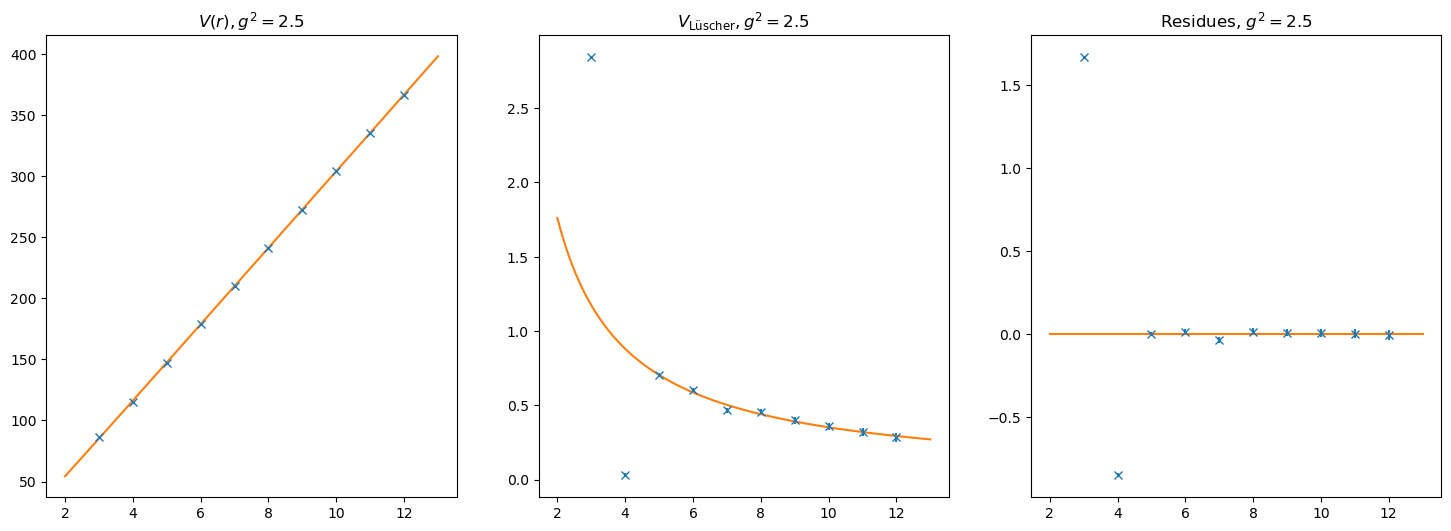

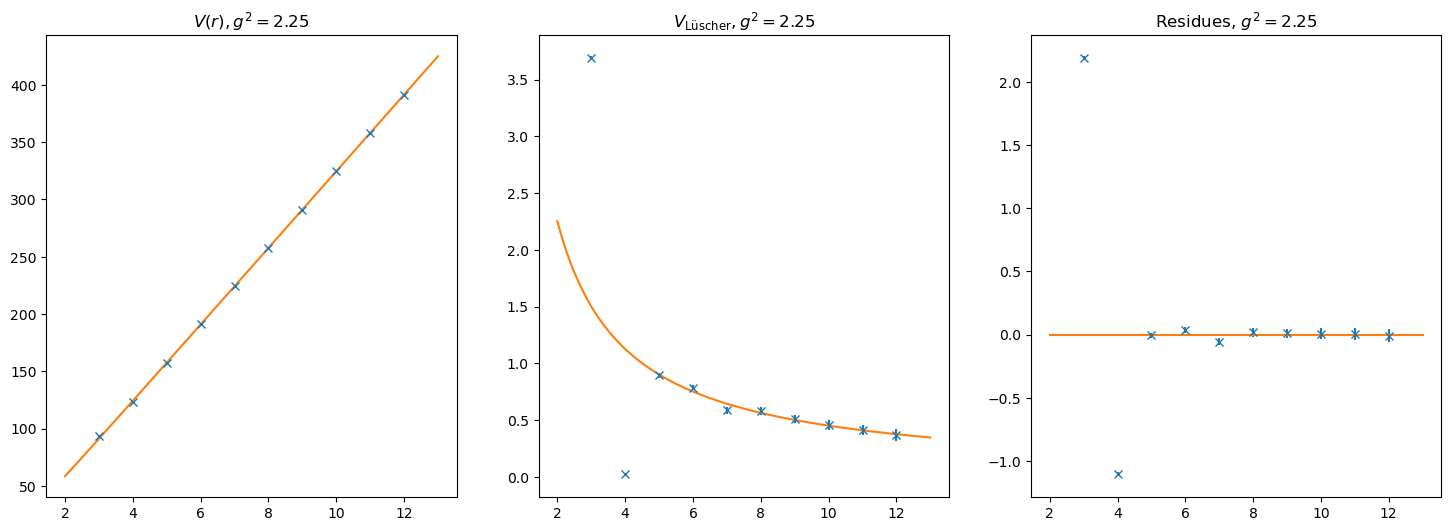

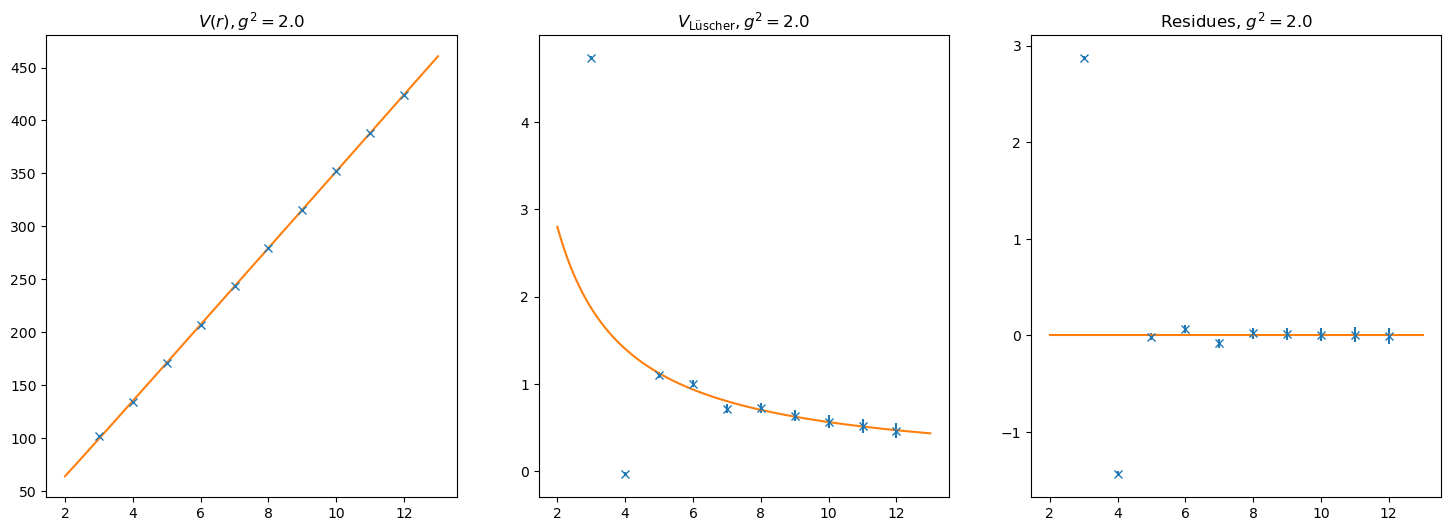

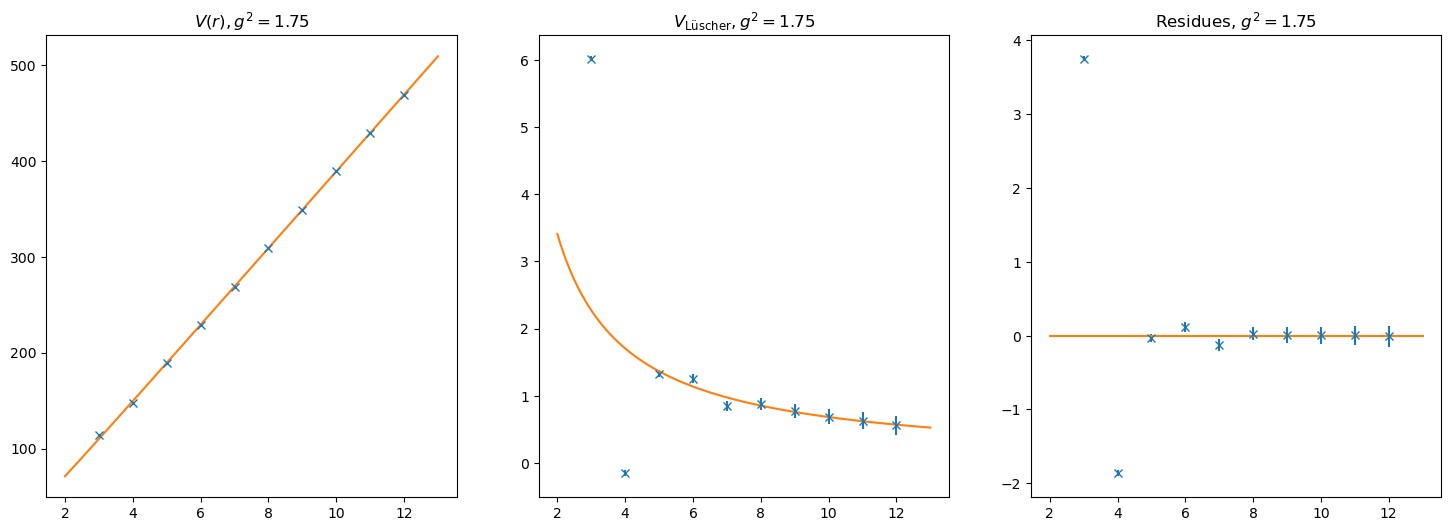

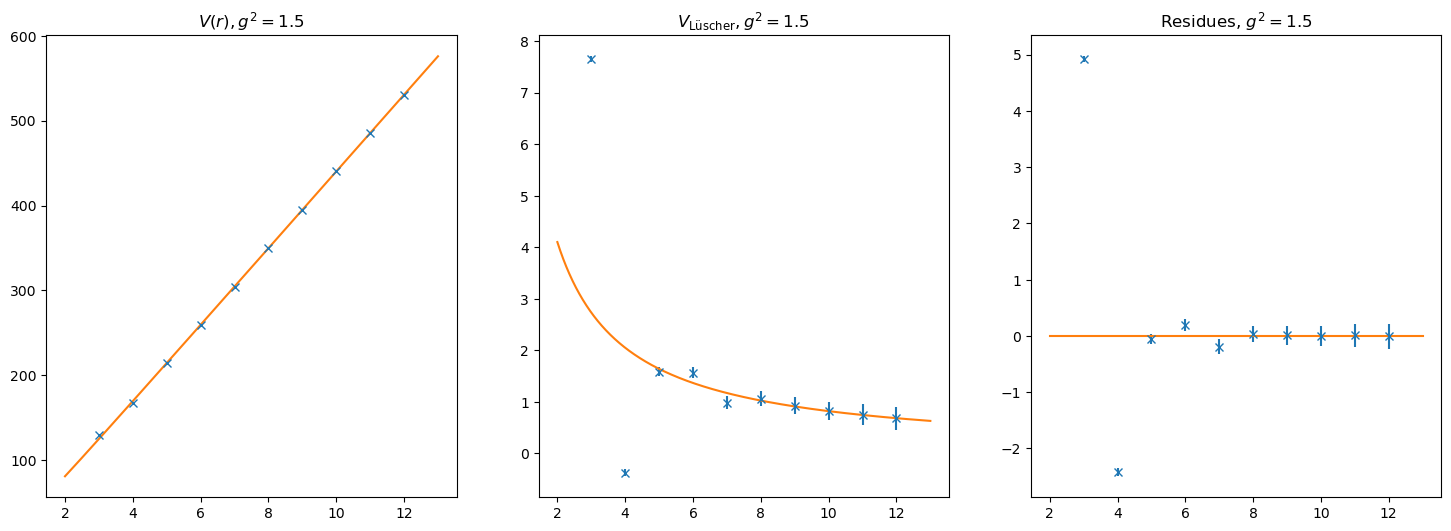

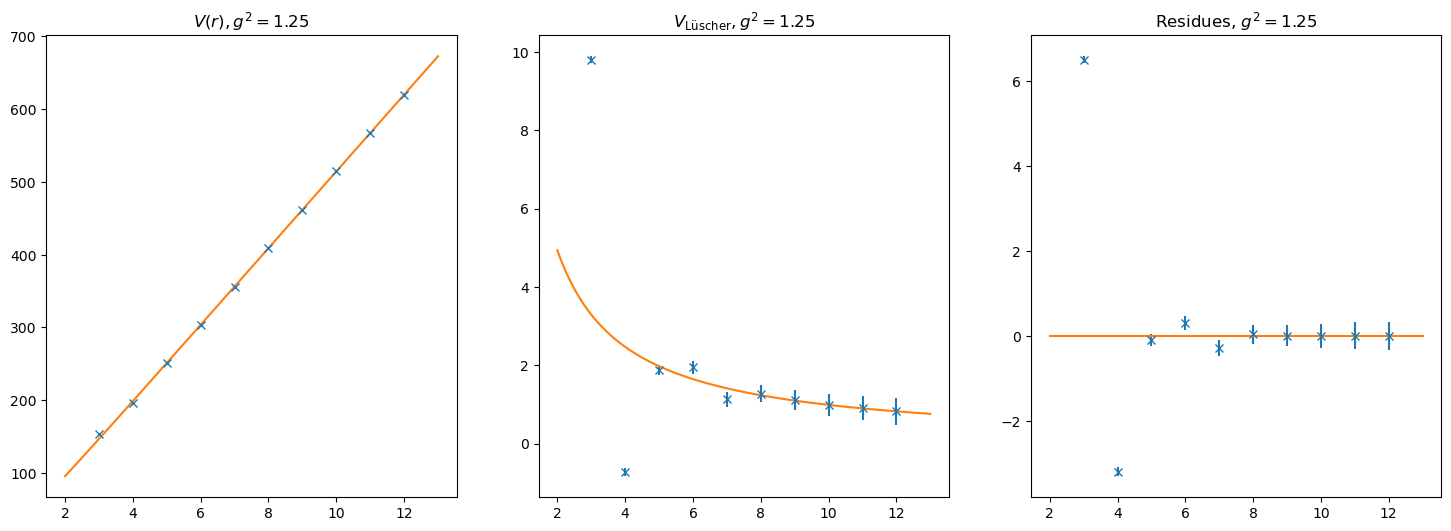

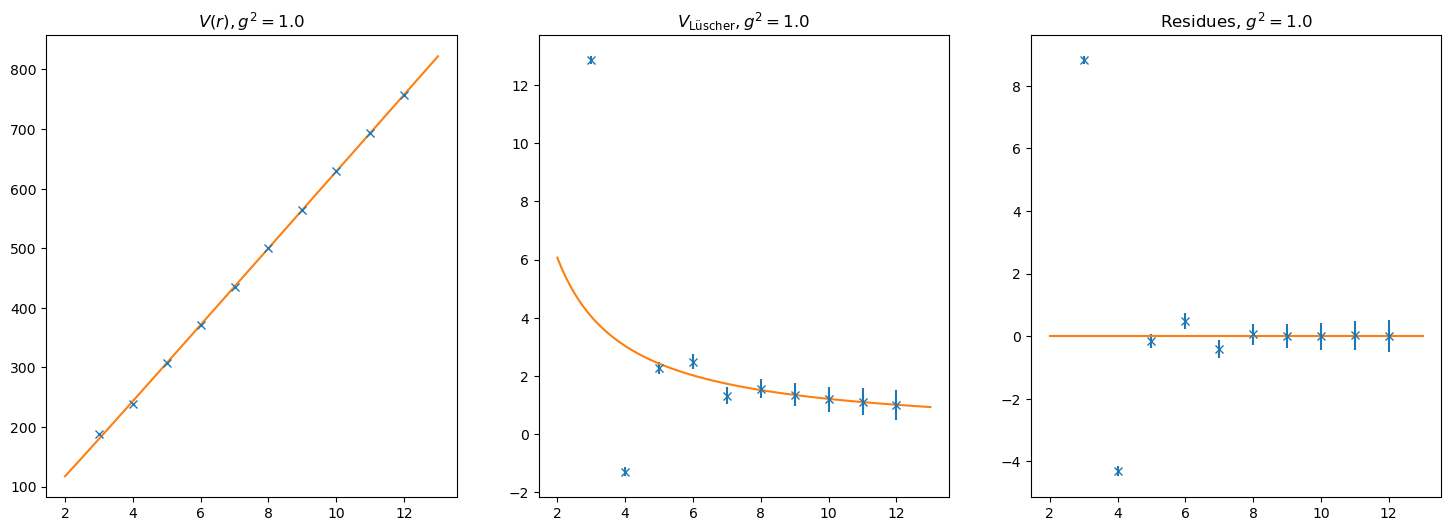

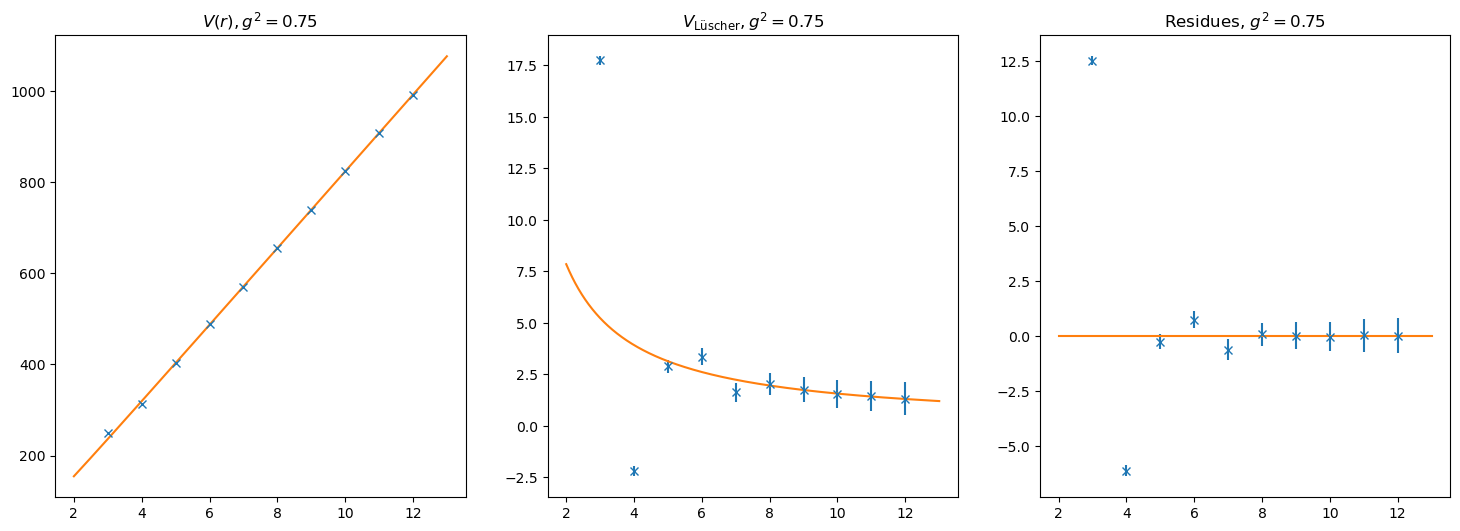

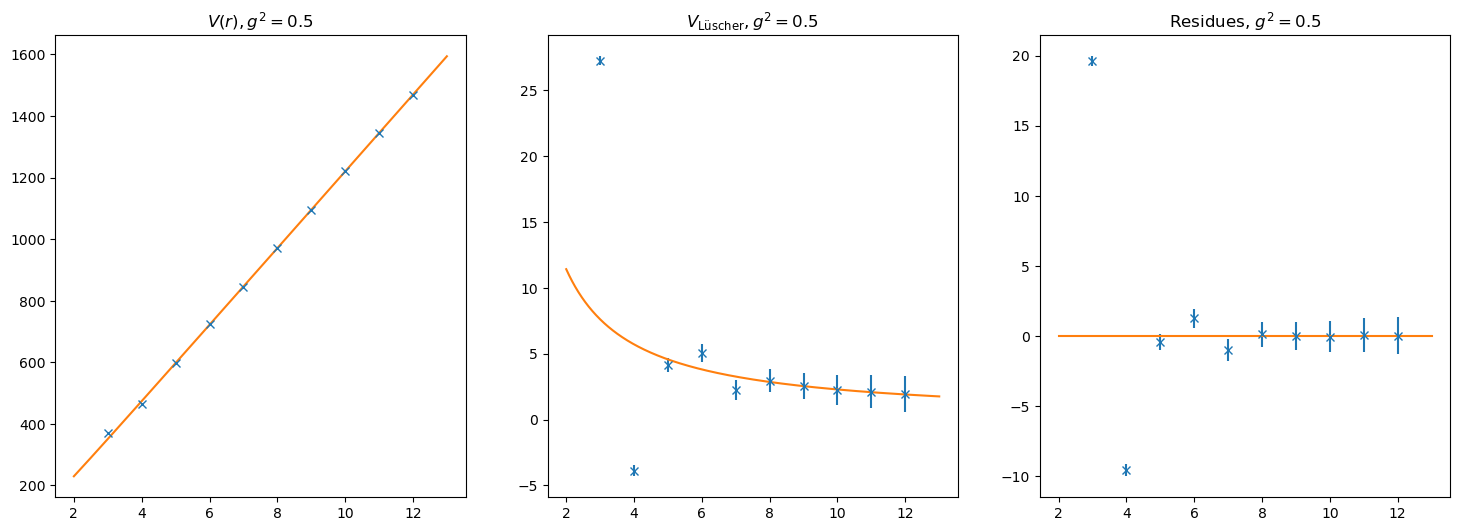

In [6]:
Nx = 4
Ny = np.arange(3, 13, 1)
Ny_fit_filter = Ny > 4
r = Ny

g2 = np.loadtxt("NX4/ground/AAA_g2_4x3.txt")

Estring = []
Eground = []

for y in Ny:
    Eground.append(np.loadtxt(f"NX4/ground/AAA_E_{Nx}x{y}.txt"))
    Estring.append(np.loadtxt(f"NX4/string/AAA_E_{Nx}x{y}.txt"))

Eground = np.array(Eground)
Estring = np.array(Estring)

V = Estring - Eground

def cornell(r, gamma, sigma, c):
    return gamma / r + sigma * r + c

def simplified(r, sigma, c):
    return sigma * r + c

gamma = []
sigma = []
c = []

for i, g in enumerate(g2):
    opt, cov = sp.optimize.curve_fit(cornell, Ny[Ny_fit_filter], V[Ny_fit_filter,i])
    # chi2 = np.sum(((V[:,i] - cornell(Ny, *opt)) / (V[:,i] * dVrel))**2) / dof = 1
    # => dVrel = np.sqrt(np.sum(((V[:,i] - cornell(Ny, *opt)) / V[:,i])**2) / dof)
    dof = len(Ny[1:]) - len(opt)
    dVrel = (np.sum(((V[Ny_fit_filter,i] - cornell(Ny[Ny_fit_filter], *opt)) / V[Ny_fit_filter,i])**2) / dof)**0.5
    chi2 = np.sum(((V[Ny_fit_filter,i] - cornell(Ny[Ny_fit_filter], *opt)) / (V[Ny_fit_filter,i] * dVrel))**2) / dof
    print(dVrel, chi2)

    Ny_fit = np.linspace(2, 13, 1000)
    gamma.append(ufloat(opt[0], cov[0][0]**0.5))
    sigma.append(ufloat(opt[1], cov[1][1]**0.5))
    c.append(ufloat(opt[2], cov[2][2]**0.5))

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].set_title(fr"$V(r), g^2={round(g, 2)}$")
    ax[0].errorbar(Ny, V[:,i], dVrel * V[:,i], fmt='x')
    ax[0].plot(Ny_fit, cornell(Ny_fit, *opt))

    ax[1].set_title(r"$V_\mathrm{L\"uscher}, g^2={" + str(round(g, 2)) + "}$")
    ax[1].errorbar(Ny, V[:,i] - simplified(Ny, opt[1], opt[2]), dVrel * np.abs(V[:,i]), fmt='x')
    ax[1].plot(Ny_fit, cornell(Ny_fit, *opt) - simplified(Ny_fit, opt[1], opt[2]))

    ax[2].set_title(r"Residues, $g^2={" + str(round(g, 2)) + "}$")
    ax[2].errorbar(Ny, V[:,i] - cornell(Ny, *opt), dVrel * np.abs(V[:,i]), fmt='x')
    ax[2].plot(Ny_fit, [0] * len(Ny_fit))
    fig.savefig(f"NX4/images/V_g2_{round(g, 2)}.png")

gamma = np.array(gamma)
sigma = np.array(sigma)
c = np.array(c)

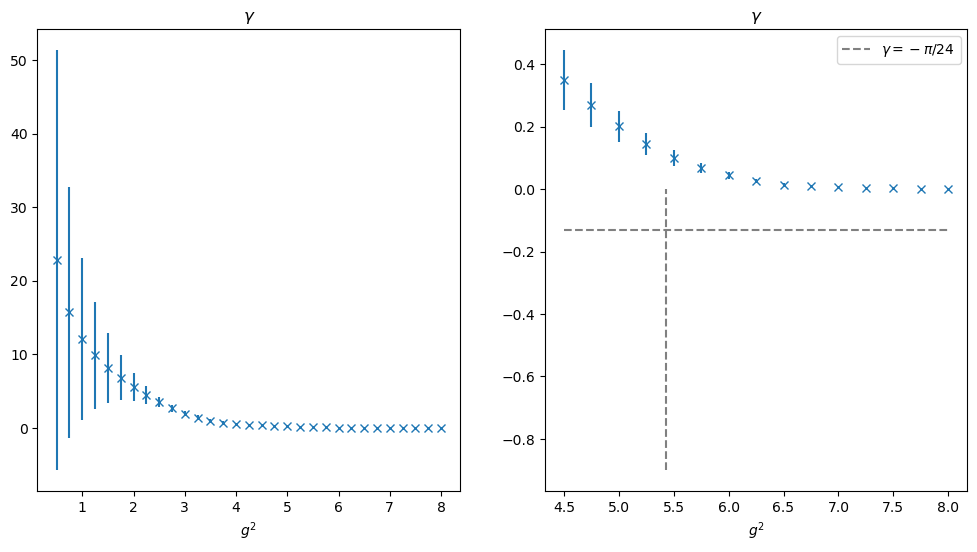

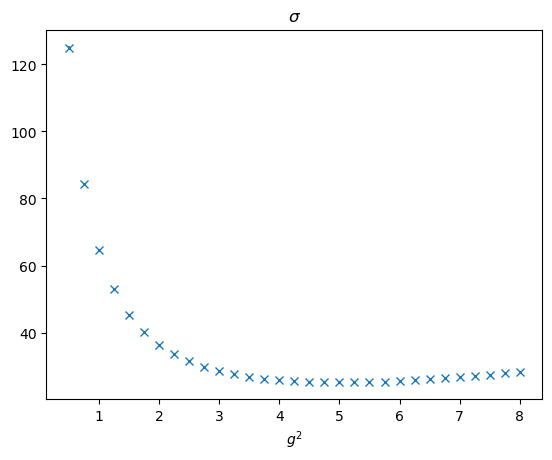

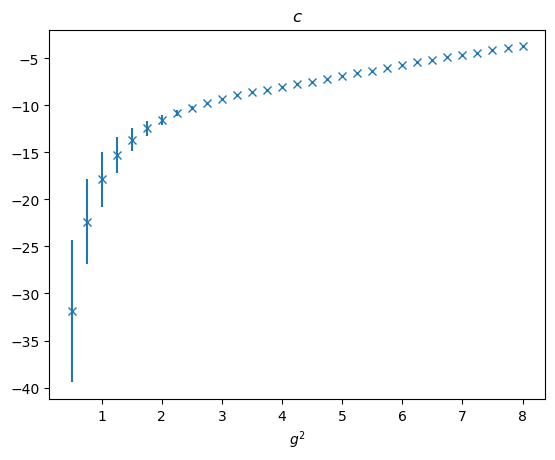

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title(r"$\gamma$")
ax[0].set_xlabel(r"$g^2$")
#ax[0].yscale("log")
ax[0].errorbar(g2, unp.nominal_values(gamma), unp.std_devs(gamma), fmt='x')

ax[1].set_title(r"$\gamma$")
ax[1].set_xlabel(r"$g^2$")
#ax[1].yscale("log")
ax[1].errorbar(g2[:-16], unp.nominal_values(gamma[:-16]), unp.std_devs(gamma[:-16]), fmt='x')
ax[1].plot([5.425]*2, [-0.9, 0], ls='--', color='gray')
ax[1].plot([4.5, 8], [-np.pi/24]*2, ls='--', color='gray', label=r"$\gamma=-\pi/24$")
ax[1].legend()
fig.savefig("NX4/images/gamma.png")

#def gamma_theo(x, a, b):
#    return a * x**b

#opt, cov = sp.optimize.curve_fit(gamma_theo, g2, unp.nominal_values(gamma), sigma=unp.std_devs(gamma), absolute_sigma=True, p0=(0, -1))
#print(unp.uarray(opt, np.diag(cov)**0.5))

#gamma_fit = np.linspace(0.25, 9, 1000)
#plt.plot(gamma_fit, gamma_theo(gamma_fit, *opt))

plt.figure()
plt.title(r"$\sigma$")
plt.xlabel(r"$g^2$")
plt.errorbar(g2, unp.nominal_values(sigma), unp.std_devs(sigma), fmt='x')
plt.savefig("NX4/images/sigma.png")

plt.figure()
plt.title(r"$c$")
plt.xlabel(r"$g^2$")
plt.errorbar(g2, unp.nominal_values(c), unp.std_devs(c), fmt='x')
plt.savefig("NX4/images/c.png")